# Notebook 01-CIC v2 — CIC-IDS2017 Data Exploration and Preprocessing

**Methodology change vs Notebook 01-CIC v1:**

- **M6 fix only**: 80/20 train/test split replaced with a 60/20/20 train/calibration/test split (stratified by 5-class label). The middle 20% calibration slice will be used by Notebook 03-CIC v2 to fit per-class isotonic calibrators. The final 20% test slice remains untouched until evaluation.

**M1 not applicable on CIC**: CIC-IDS2017 features are all numerical (no proto/service/state categorical columns). No one-hot encoding, no encoder leak.

Other design decisions (200K proportional subsample with 1000-per-class floor, inf/NaN cleaning, StandardScaler fit on train) are unchanged from v1.

**Note on CIC's lack of official partition**: NSL-KDD and UNSW-NB15 have official train/test partitions provided by the dataset authors. CIC-IDS2017 does not. v1 created an 80/20 random stratified split; v2 creates a 60/20/20 random stratified split. This is a methodologically cleaner design but does not address Engelen et al.'s known labelling issues, which remain documented as future work.

**Files written to `data/processed/cic_ids2017_v2/`** (parallel directory to v1):

| File | Shape | Notes |
|---|---|---|
| `X_train.npy` | (~120,000, 78) | 60% train slice (was 80% in v1) |
| `X_calib.npy` | (~40,000, 78) | **NEW** — 20% calibration slice |
| `X_test.npy` | (~40,000, 78) | 20% test slice (was 20% in v1, untouched after split) |
| `y_train_binary.npy`, `y_train_5class.npy` | (~120,000,) | Train labels |
| `y_calib_binary.npy`, `y_calib_5class.npy` | (~40,000,) | **NEW** — calibration labels |
| `y_test_binary.npy`, `y_test_5class.npy` | (~40,000,) | Test labels |
| `idx_train_in_all.npy`, `idx_calib_in_all.npy`, `idx_test_in_all.npy` | varies | **NEW** — indices into the 200K pool |
| `split_methodology.json` | — | **NEW** — paper-ready split description |
| `feature_names.json`, `class_mappings.json`, `scaler.pkl` | — | unchanged from v1 |

## 1. Setup

In [4]:
from google.colab import drive
drive.mount('/content/drive')

import os, shutil
REPO = '/content/drive/MyDrive/XIDS_Research/xids-research'
os.chdir(REPO)

for f in ['.gitconfig', '.git-credentials']:
    src = f'/content/drive/MyDrive/XIDS_Research/{f}'
    if os.path.exists(src):
        shutil.copy(src, f'/root/{f}')
        if f == '.git-credentials':
            os.chmod(f'/root/{f}', 0o600)

!git pull
print(f'✓ Ready in: {os.getcwd()}')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Already up to date.
✓ Ready in: /content/drive/MyDrive/XIDS_Research/xids-research


In [5]:
import numpy as np
import pandas as pd
import json, pickle, glob, gc
from pathlib import Path
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt

SEED = 42
np.random.seed(SEED)

RAW_DIR = Path(REPO) / 'data' / 'raw' / 'cic_ids2017'
OUT_DIR = Path(REPO) / 'data' / 'processed' / 'cic_ids2017_v2'
OUT_DIR.mkdir(parents=True, exist_ok=True)
FIG_DIR = Path(REPO) / 'results' / 'figures'
FIG_DIR.mkdir(parents=True, exist_ok=True)

print(f'Raw dir: {RAW_DIR}')
print(f'Out dir: {OUT_DIR}')
print(f'\nFiles in raw dir:')
for f in sorted(RAW_DIR.glob('*.csv')):
    size_mb = f.stat().st_size / 1024**2
    print(f'  {f.name}  ({size_mb:.1f} MB)')

Raw dir: /content/drive/MyDrive/XIDS_Research/xids-research/data/raw/cic_ids2017
Out dir: /content/drive/MyDrive/XIDS_Research/xids-research/data/processed/cic_ids2017_v2

Files in raw dir:
  Friday-WorkingHours-Afternoon-DDos.pcap_ISCX.csv  (73.6 MB)
  Friday-WorkingHours-Afternoon-PortScan.pcap_ISCX.csv  (73.3 MB)
  Friday-WorkingHours-Morning.pcap_ISCX.csv  (55.6 MB)
  Monday-WorkingHours.pcap_ISCX.csv  (168.7 MB)
  Thursday-WorkingHours-Afternoon-Infilteration.pcap_ISCX.csv  (79.3 MB)
  Thursday-WorkingHours-Morning-WebAttacks.pcap_ISCX.csv  (49.6 MB)
  Tuesday-WorkingHours.pcap_ISCX.csv  (128.8 MB)
  Wednesday-workingHours.pcap_ISCX.csv  (214.7 MB)


In [6]:
from google.colab import drive
drive.mount('/content/drive', force_remount=True)

# Verify it's back
import os
print(f'Drive mounted: {os.path.exists("/content/drive/MyDrive/XIDS_Research/xids-research")}')

Mounted at /content/drive
Drive mounted: True


## 2. Load and combine all CSVs

In [7]:
csv_files = sorted(RAW_DIR.glob('*.csv'))

dfs = []
for f in csv_files:
    df = pd.read_csv(f, low_memory=False)
    print(f'  {f.name:<60}: {df.shape}')
    dfs.append(df)

df_all = pd.concat(dfs, ignore_index=True)
del dfs; gc.collect()
print(f'\nCombined shape: {df_all.shape}')
print(f'Memory: {df_all.memory_usage(deep=True).sum() / 1024**2:.1f} MB')

  Friday-WorkingHours-Afternoon-DDos.pcap_ISCX.csv            : (225745, 79)
  Friday-WorkingHours-Afternoon-PortScan.pcap_ISCX.csv        : (286467, 79)
  Friday-WorkingHours-Morning.pcap_ISCX.csv                   : (191033, 79)
  Monday-WorkingHours.pcap_ISCX.csv                           : (529918, 79)
  Thursday-WorkingHours-Afternoon-Infilteration.pcap_ISCX.csv : (288602, 79)
  Thursday-WorkingHours-Morning-WebAttacks.pcap_ISCX.csv      : (170366, 79)
  Tuesday-WorkingHours.pcap_ISCX.csv                          : (445909, 79)
  Wednesday-workingHours.pcap_ISCX.csv                        : (692703, 79)

Combined shape: (2830743, 79)
Memory: 1833.9 MB


In [8]:
# Strip whitespace from column names (CIC has many ' Label' style columns)
df_all.columns = df_all.columns.str.strip()

print(f'Total columns: {len(df_all.columns)}')
print(f'First 10 columns: {list(df_all.columns[:10])}')
print(f'Last column (should be Label): {df_all.columns[-1]}')

Total columns: 79
First 10 columns: ['Destination Port', 'Flow Duration', 'Total Fwd Packets', 'Total Backward Packets', 'Total Length of Fwd Packets', 'Total Length of Bwd Packets', 'Fwd Packet Length Max', 'Fwd Packet Length Min', 'Fwd Packet Length Mean', 'Fwd Packet Length Std']
Last column (should be Label): Label


## 3. Clean inf/NaN

In [9]:
n_before = len(df_all)
df_all = df_all.replace([np.inf, -np.inf], np.nan)
n_after = df_all.dropna().shape[0]
n_dropped = n_before - n_after
df_all = df_all.dropna()
df_all = df_all.reset_index(drop=True)

print(f'Rows before cleaning: {n_before:,}')
print(f'Rows dropped (inf/NaN): {n_dropped:,}')
print(f'Rows remaining: {len(df_all):,}')

Rows before cleaning: 2,830,743
Rows dropped (inf/NaN): 2,867
Rows remaining: 2,827,876


## 4. Map CIC labels → 5-class taxonomy

In [10]:
print('Original label distribution:')
print(df_all['Label'].value_counts())

LABEL_MAPPING = {
    'BENIGN': 'Normal',
    'DoS Hulk': 'DoS', 'DoS GoldenEye': 'DoS', 'DoS slowloris': 'DoS',
    'DoS Slowhttptest': 'DoS', 'DDoS': 'DoS', 'Heartbleed': 'DoS',
    'PortScan': 'Probe',
    'FTP-Patator': 'R2L', 'SSH-Patator': 'R2L',
    'Web Attack \x96 Brute Force': 'R2L',
    'Web Attack \x96 XSS': 'R2L',
    'Web Attack \x96 Sql Injection': 'R2L',
    'Bot': 'R2L',
    'Infiltration': 'U2R',
}

df_all['Category'] = df_all['Label'].map(LABEL_MAPPING)

unmapped = df_all[df_all['Category'].isnull()]['Label'].unique()
if len(unmapped) > 0:
    print(f'\n⚠ Unmapped labels: {unmapped}')
    n_before = len(df_all)
    df_all = df_all.dropna(subset=['Category']).reset_index(drop=True)
    print(f'  Dropped {n_before - len(df_all):,} unmapped rows')

print(f'\n5-class distribution:')
print(df_all['Category'].value_counts())

Original label distribution:
Label
BENIGN                        2271320
DoS Hulk                       230124
PortScan                       158804
DDoS                           128025
DoS GoldenEye                   10293
FTP-Patator                      7935
SSH-Patator                      5897
DoS slowloris                    5796
DoS Slowhttptest                 5499
Bot                              1956
Web Attack � Brute Force         1507
Web Attack � XSS                  652
Infiltration                       36
Web Attack � Sql Injection         21
Heartbleed                         11
Name: count, dtype: int64

⚠ Unmapped labels: ['Web Attack � Brute Force' 'Web Attack � XSS'
 'Web Attack � Sql Injection']
  Dropped 2,180 unmapped rows

5-class distribution:
Category
Normal    2271320
DoS        379748
Probe      158804
R2L         15788
U2R            36
Name: count, dtype: int64


## 5. Subsample to ~200K rows (proportional + 1000-per-class floor)

In [11]:
TARGET_TOTAL = 200_000
MIN_PER_CLASS = 1_000

category_counts = df_all['Category'].value_counts().to_dict()
print(f'Original counts:')
for cat, n in category_counts.items():
    print(f'  {cat}: {n:,}')

total = sum(category_counts.values())
subsample_counts = {}
for cat, n in category_counts.items():
    proportional = int(n / total * TARGET_TOTAL)
    take = min(n, max(proportional, MIN_PER_CLASS))
    subsample_counts[cat] = take

print(f'\nTarget subsample counts:')
for cat, n in subsample_counts.items():
    print(f'  {cat}: {n:,}')

subsamples = []
for cat, n_take in subsample_counts.items():
    pool = df_all[df_all['Category'] == cat]
    if len(pool) <= n_take:
        subsamples.append(pool)
    else:
        subsamples.append(pool.sample(n=n_take, random_state=SEED))

df_sub = pd.concat(subsamples, ignore_index=True)
df_sub = df_sub.sample(frac=1, random_state=SEED).reset_index(drop=True)

del df_all; gc.collect()

print(f'\nFinal subsample: {len(df_sub):,} rows')
print(df_sub['Category'].value_counts())

Original counts:
  Normal: 2,271,320
  DoS: 379,748
  Probe: 158,804
  R2L: 15,788
  U2R: 36

Target subsample counts:
  Normal: 160,761
  DoS: 26,878
  Probe: 11,239
  R2L: 1,117
  U2R: 36

Final subsample: 200,031 rows
Category
Normal    160761
DoS        26878
Probe      11239
R2L         1117
U2R           36
Name: count, dtype: int64


## 6. Separate features and labels

In [12]:
feature_cols = [c for c in df_sub.columns if c not in ['Label', 'Category']]
X = df_sub[feature_cols].values.astype(np.float32)

print(f'Feature matrix shape: {X.shape}')
print(f'Feature columns: {feature_cols[:5]}... (+{len(feature_cols)-5} more)')

y_binary = (df_sub['Category'] != 'Normal').astype(np.int64).values

CATEGORY_TO_INT = {'Normal': 0, 'DoS': 1, 'Probe': 2, 'R2L': 3, 'U2R': 4}
INT_TO_CATEGORY = {v: k for k, v in CATEGORY_TO_INT.items()}
y_5class = df_sub['Category'].map(CATEGORY_TO_INT).astype(np.int64).values

print(f'\nBinary distribution: Normal={np.sum(y_binary==0):,}, Attack={np.sum(y_binary==1):,}')
print(f'\n5-class distribution:')
for i in range(5):
    print(f'  {i} = {INT_TO_CATEGORY[i]:8s}  → {np.sum(y_5class==i):>7,}')

Feature matrix shape: (200031, 78)
Feature columns: ['Destination Port', 'Flow Duration', 'Total Fwd Packets', 'Total Backward Packets', 'Total Length of Fwd Packets']... (+73 more)

Binary distribution: Normal=160,761, Attack=39,270

5-class distribution:
  0 = Normal    → 160,761
  1 = DoS       →  26,878
  2 = Probe     →  11,239
  3 = R2L       →   1,117
  4 = U2R       →      36


## 7. M6 FIX: 60/20/20 train/calibration/test split

v1 used 80/20 train/test. v2 carves an additional 20% calibration slice out of what was previously the training side. Two stratified splits are needed: first separate 20% as the held-out test set, then split the remaining 80% into 75/25 (which gives 60/20 of the original).

In [13]:
idx_all = np.arange(len(X))

# First split: 80% train+calib vs 20% test (stratified by 5-class)
idx_trncal, idx_test = train_test_split(
    idx_all,
    test_size=0.20,
    stratify=y_5class,
    random_state=SEED,
)

# Second split: 75/25 of the 80% → gives 60/20 of the total (stratified by 5-class)
y_trncal = y_5class[idx_trncal]
idx_train_local, idx_calib_local = train_test_split(
    np.arange(len(idx_trncal)),
    test_size=0.25,
    stratify=y_trncal,
    random_state=SEED,
)

# Map second-split local indices back to indices into the full pool
idx_train = idx_trncal[idx_train_local]
idx_calib = idx_trncal[idx_calib_local]

# Carve out the splits
X_train_raw = X[idx_train]
X_calib_raw = X[idx_calib]
X_test_raw  = X[idx_test]

y_train_binary = y_binary[idx_train]
y_calib_binary = y_binary[idx_calib]
y_test_binary  = y_binary[idx_test]

y_train_5class = y_5class[idx_train]
y_calib_5class = y_5class[idx_calib]
y_test_5class  = y_5class[idx_test]

print(f'60/20/20 split (stratified by 5-class):')
print(f'  Train: {len(idx_train):,} samples ({len(idx_train)/len(X)*100:.1f}%)')
print(f'  Calib: {len(idx_calib):,} samples ({len(idx_calib)/len(X)*100:.1f}%)')
print(f'  Test:  {len(idx_test):,} samples ({len(idx_test)/len(X)*100:.1f}%)')

print(f'\nPer-class distribution after split:')
print(f'  {"Class":<10}  {"Train":>10}  {"Calib":>10}  {"Test":>10}')
for c in range(5):
    n_train = int(np.sum(y_train_5class == c))
    n_calib = int(np.sum(y_calib_5class == c))
    n_test  = int(np.sum(y_test_5class == c))
    print(f'  {INT_TO_CATEGORY[c]:<10}  {n_train:>10,}  {n_calib:>10,}  {n_test:>10,}')

60/20/20 split (stratified by 5-class):
  Train: 120,018 samples (60.0%)
  Calib: 40,006 samples (20.0%)
  Test:  40,007 samples (20.0%)

Per-class distribution after split:
  Class            Train       Calib        Test
  Normal          96,456      32,152      32,153
  DoS             16,126       5,376       5,376
  Probe            6,743       2,248       2,248
  R2L                671         223         223
  U2R                 22           7           7


## 8. Standardisation (StandardScaler fit on train only)

In [14]:
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train_raw).astype(np.float32)
X_calib = scaler.transform(X_calib_raw).astype(np.float32)
X_test  = scaler.transform(X_test_raw).astype(np.float32)

print(f'After standardisation:')
print(f'  X_train: shape={X_train.shape}, mean={X_train.mean():.4f}, std={X_train.std():.4f}')
print(f'  X_calib: shape={X_calib.shape}, mean={X_calib.mean():.4f}, std={X_calib.std():.4f}')
print(f'  X_test:  shape={X_test.shape},  mean={X_test.mean():.4f},  std={X_test.std():.4f}')
print(f'\nNote: calib and test stats won\'t be exactly 0/1 (scaler fit on train only — by design).')

After standardisation:
  X_train: shape=(120018, 78), mean=-0.0000, std=0.9473
  X_calib: shape=(40006, 78), mean=-0.0018, std=0.8431
  X_test:  shape=(40007, 78),  mean=0.0016,  std=0.9518

Note: calib and test stats won't be exactly 0/1 (scaler fit on train only — by design).


## 9. Class-distribution figure

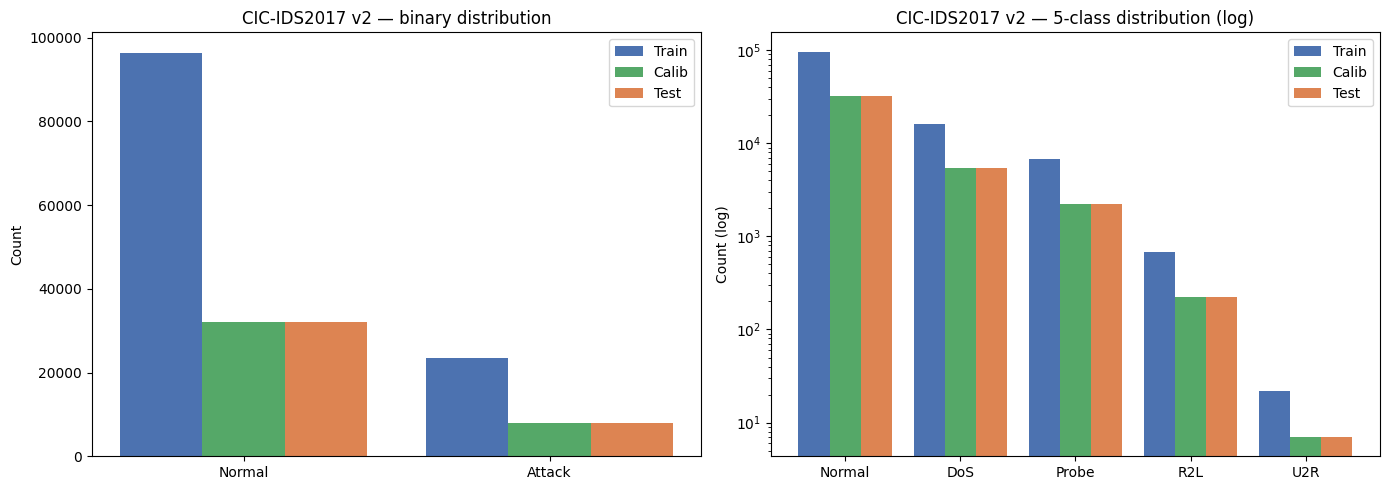


Saved figure: /content/drive/MyDrive/XIDS_Research/xids-research/results/figures/cic_v2_class_distribution.png


In [15]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Binary: train / calib / test
x = np.arange(2)
w = 0.27
for offset, vals, label, colour in [
    (-w, [int(np.sum(y_train_binary==0)), int(np.sum(y_train_binary==1))], 'Train', '#4C72B0'),
    (0,  [int(np.sum(y_calib_binary==0)), int(np.sum(y_calib_binary==1))], 'Calib', '#55A868'),
    (w,  [int(np.sum(y_test_binary==0)),  int(np.sum(y_test_binary==1))],  'Test',  '#DD8452'),
]:
    axes[0].bar(x + offset, vals, w, label=label, color=colour)
axes[0].set_xticks(x); axes[0].set_xticklabels(['Normal', 'Attack'])
axes[0].set_title('CIC-IDS2017 v2 — binary distribution')
axes[0].set_ylabel('Count')
axes[0].legend()

# 5-class (log scale)
names = [INT_TO_CATEGORY[i] for i in range(5)]
x = np.arange(5)
for offset, ys, label, colour in [
    (-w, y_train_5class, 'Train', '#4C72B0'),
    (0,  y_calib_5class, 'Calib', '#55A868'),
    (w,  y_test_5class,  'Test',  '#DD8452'),
]:
    vals = [int(np.sum(ys == i)) for i in range(5)]
    axes[1].bar(x + offset, vals, w, label=label, color=colour)
axes[1].set_xticks(x); axes[1].set_xticklabels(names)
axes[1].set_title('CIC-IDS2017 v2 — 5-class distribution (log)')
axes[1].set_ylabel('Count (log)')
axes[1].set_yscale('log')
axes[1].legend()

plt.tight_layout()
fig_path = FIG_DIR / 'cic_v2_class_distribution.png'
plt.savefig(fig_path, dpi=150, bbox_inches='tight')
plt.show()
print(f'\nSaved figure: {fig_path}')

## 10. Save processed files

In [16]:
# Feature arrays
np.save(OUT_DIR / 'X_train.npy', X_train)
np.save(OUT_DIR / 'X_calib.npy', X_calib)
np.save(OUT_DIR / 'X_test.npy',  X_test)

# Binary labels
np.save(OUT_DIR / 'y_train_binary.npy', y_train_binary)
np.save(OUT_DIR / 'y_calib_binary.npy', y_calib_binary)
np.save(OUT_DIR / 'y_test_binary.npy',  y_test_binary)

# 5-class labels
np.save(OUT_DIR / 'y_train_5class.npy', y_train_5class)
np.save(OUT_DIR / 'y_calib_5class.npy', y_calib_5class)
np.save(OUT_DIR / 'y_test_5class.npy',  y_test_5class)

# Indices into the 200K subsample pool
np.save(OUT_DIR / 'idx_train_in_all.npy', idx_train)
np.save(OUT_DIR / 'idx_calib_in_all.npy', idx_calib)
np.save(OUT_DIR / 'idx_test_in_all.npy',  idx_test)

# Feature names
with open(OUT_DIR / 'feature_names.json', 'w') as f:
    json.dump(feature_cols, f, indent=2)

# Class mappings
class_info = {
    'binary': {'0': 'Normal', '1': 'Attack'},
    'multiclass_5': INT_TO_CATEGORY,
    'label_mapping': LABEL_MAPPING,
    'note': 'Engelen WTMC-2021 corrections not applied; future work.',
}
with open(OUT_DIR / 'class_mappings.json', 'w') as f:
    json.dump(class_info, f, indent=2)

# Scaler
with open(OUT_DIR / 'scaler.pkl', 'wb') as f:
    pickle.dump(scaler, f)

# Methodology summary
methodology = {
    'version': 'v2',
    'design': 'train/calibration/test (three-way) split on 200K stratified subsample',
    'subsample_total': int(len(X)),
    'train_size': int(len(X_train)),
    'calib_size': int(len(X_calib)),
    'test_size': int(len(X_test)),
    'split_method': 'two-stage stratified by 5-class label, random_state=SEED, final ratio 60/20/20',
    'fixes_vs_v1': [
        'M6: 80/20 train/test in v1 → 60/20/20 train/calibration/test in v2',
    ],
    'notes': [
        'CIC-IDS2017 has no official train/test partition; we create one via stratified random split',
        'Train portion: model fitting (Notebook 02-CIC v2)',
        'Calibration portion: per-class isotonic calibrators (Notebook 03-CIC v2)',
        'Test portion: untouched until evaluation',
        'M1 not applicable on CIC (no categorical features)',
    ],
}
with open(OUT_DIR / 'split_methodology.json', 'w') as f:
    json.dump(methodology, f, indent=2)

print(f'✓ Saved all v2 processed files to: {OUT_DIR}\n')
for p in sorted(OUT_DIR.iterdir()):
    if p.is_file():
        print(f'  {p.name:<30}  {p.stat().st_size/1024:>10,.1f} KB')

✓ Saved all v2 processed files to: /content/drive/MyDrive/XIDS_Research/xids-research/data/processed/cic_ids2017_v2

  X_calib.npy                       12,189.5 KB
  X_test.npy                        12,189.8 KB
  X_train.npy                       36,568.1 KB
  class_mappings.json                    0.7 KB
  feature_names.json                     1.7 KB
  idx_calib_in_all.npy                 312.7 KB
  idx_test_in_all.npy                  312.7 KB
  idx_train_in_all.npy                 937.8 KB
  scaler.pkl                             2.3 KB
  split_methodology.json                 0.7 KB
  y_calib_5class.npy                   312.7 KB
  y_calib_binary.npy                   312.7 KB
  y_test_5class.npy                    312.7 KB
  y_test_binary.npy                    312.7 KB
  y_train_5class.npy                   937.8 KB
  y_train_binary.npy                   937.8 KB


## 11. Round-trip verification

In [17]:
X_train_r = np.load(OUT_DIR / 'X_train.npy')
X_calib_r = np.load(OUT_DIR / 'X_calib.npy')
X_test_r  = np.load(OUT_DIR / 'X_test.npy')

assert X_train_r.shape == X_train.shape
assert X_calib_r.shape == X_calib.shape
assert X_test_r.shape  == X_test.shape

# Disjointness across all three splits
idx_train_check = np.load(OUT_DIR / 'idx_train_in_all.npy')
idx_calib_check = np.load(OUT_DIR / 'idx_calib_in_all.npy')
idx_test_check  = np.load(OUT_DIR / 'idx_test_in_all.npy')

overlap_tc = set(idx_train_check) & set(idx_calib_check)
overlap_tt = set(idx_train_check) & set(idx_test_check)
overlap_ct = set(idx_calib_check) & set(idx_test_check)

assert len(overlap_tc) == 0, f'Train/calib overlap: {len(overlap_tc)} leak'
assert len(overlap_tt) == 0, f'Train/test overlap: {len(overlap_tt)} leak'
assert len(overlap_ct) == 0, f'Calib/test overlap: {len(overlap_ct)} leak'

# Coverage: all three should sum to the subsample size
total = len(idx_train_check) + len(idx_calib_check) + len(idx_test_check)
assert total == len(X), f'Train+calib+test ({total}) != total subsample ({len(X)})'

print('✓ All files round-trip correctly.')
print('✓ Train, calibration, and test sets are pairwise disjoint.')
print('✓ Train + calibration + test covers the 200K subsample exactly.')
print()
print(f'Shapes:')
print(f'  X_train: {X_train_r.shape}  (60% of subsample)')
print(f'  X_calib: {X_calib_r.shape}  (20% of subsample)')
print(f'  X_test:  {X_test_r.shape}   (20% of subsample)')

✓ All files round-trip correctly.
✓ Train, calibration, and test sets are pairwise disjoint.
✓ Train + calibration + test covers the 200K subsample exactly.

Shapes:
  X_train: (120018, 78)  (60% of subsample)
  X_calib: (40006, 78)  (20% of subsample)
  X_test:  (40007, 78)   (20% of subsample)


## 12. Commit and push

In [18]:
os.chdir(REPO)
!git add notebooks/01_cic_data_exploration_v2.ipynb
!git add results/figures/cic_v2_class_distribution.png
!git status --short
!git commit -m 'Notebook 01-CIC v2: CIC-IDS2017 preprocessing with M6 fix (60/20/20 train/calib/test split)'
!git push origin main

Refresh index: 100% (224/224), done.
A  notebooks/01_cic_data_exploration_v2.ipynb
 M notebooks/01_data_exploration_v2.ipynb
 M notebooks/01_unsw_data_exploration_v2.ipynb
A  results/figures/cic_v2_class_distribution.png
?? calibrators/
?? models/
?? notebooks/02b_unsw_dnn_diagnostic.ipynb
?? results/figures/unsw_dnn_5class_diagnostic.png
?? shap_values/unsw_nb15/
[main cd6fe2c] Notebook 01-CIC v2: CIC-IDS2017 preprocessing with M6 fix (60/20/20 train/calib/test split)
 2 files changed, 1 insertion(+)
 create mode 100644 notebooks/01_cic_data_exploration_v2.ipynb
 create mode 100644 results/figures/cic_v2_class_distribution.png
Enumerating objects: 11, done.
Counting objects: 100% (11/11), done.
Delta compression using up to 2 threads
Compressing objects: 100% (7/7), done.
Writing objects: 100% (7/7), 47.52 KiB | 2.38 MiB/s, done.
Total 7 (delta 4), reused 0 (delta 0), pack-reused 0
remote: Resolving deltas: 100% (4/4), completed with 4 local objects.
To https://github.com/anasbiswas1/